# Prediksi Klaim Asuransi Kesehatan (Data Science Competition)

Notebook ini merupakan solusi end-to-end untuk memprediksi `Claim_Frequency`, `Claim_Severity`, dan `Total_Claim` selama 5 bulan ke depan (Agustus - Desember 2025).

Solusi ini menggunakan pendekatan **Machine Learning Hibrida (Ensemble)** yang menggabungkan statistika *time-series* klasik dengan regresi linear berbasis *autoregressive*.

## 1. Import Library & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import BayesianRidge, Ridge
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

import warnings
warnings.filterwarnings('ignore')

# Setelan tema visualisasi
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (15, 6)

# Membaca dataset
df_klaim = pd.read_csv('Data_Klaim.csv')
display(df_klaim.head())

,Claim ID,Nomor Polis,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description,Status Klaim,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Lokasi RS
0,C-0001-M,POL-0176,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,2024-07-08,2024-05-27,2024-05-27,28093653.0,6.143948e+06,Singapore
1,C-0002-M,POL-3288,R,OP,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,PAID,2024-08-06,2024-07-15,2024-07-15,80987278.0,8.230952e+07,Malaysia
2,C-0003-M,POL-1786,R,OP,C18.9,"MALIGNANT NEOPLASM, COLON, UNSPECIFIED",PAID,2024-10-17,2024-05-16,2024-05-16,183047130.0,1.928599e+08,Singapore
3,C-0004-M,POL-1786,R,OP,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,PAID,2024-09-03,2024-07-18,2024-07-18,191424386.0,1.914244e+08,Singapore
4,C-0005-M,POL-2778,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,NaN,2024-06-06,2024-06-06,138936357.0,1.389364e+08,Singapore


## 2. Preprocessing & Pembersihan Data
Tahapan ini memastikan data terbebas dari anomali ekstrem sebelum dilatih:
1. **Filter PAID:** Hanya mengambil klaim yang statusnya disetujui.
2. **Capping (98.0%):** Memotong nilai tagihan rumah sakit yang bersifat *outlier* ekstrem pada persentil 98.0% agar model linear tidak melenceng.
3. **IBNR Adjustment (Incurred But Not Reported):** Mengoreksi data bulan terakhir (Juli 2025) yang biasanya menurun tajam karena keterlambatan rumah sakit mengirim tagihan, dengan mengalikannya 1.4x sebagai *baseline* yang lebih realistis.
4. **Post-Covid Filter:** Model hanya dilatih menggunakan tren data pasca-pandemi (mulai 2022).

In [2]:
date_col = 'Tanggal Pasien Masuk RS'
df_klaim[date_col] = pd.to_datetime(df_klaim[date_col], errors='coerce')
df_klaim = df_klaim.dropna(subset=[date_col])

df_klaim_paid = df_klaim[df_klaim['Status Klaim'] == 'PAID'].copy()

# Capping di 98.0%
limit = df_klaim_paid['Nominal Klaim Yang Disetujui'].quantile(0.980)
df_klaim_paid['Nominal_Klaim_Capped'] = np.clip(df_klaim_paid['Nominal Klaim Yang Disetujui'], a_min=0, a_max=limit)

df_klaim_paid['YearMonth'] = df_klaim_paid[date_col].dt.to_period('M').astype(str)

# Agregasi Data per Bulan
monthly_data = df_klaim_paid.groupby('YearMonth').agg(
    Claim_Frequency=('Claim ID', 'count'),
    Total_Claim=('Nominal_Klaim_Capped', 'sum') 
).reset_index()

monthly_data['Date'] = pd.to_datetime(monthly_data['YearMonth'] + '-01')
monthly_data = monthly_data.sort_values('Date').reset_index(drop=True)

# Penyesuaian IBNR (Batu Loncatan Akhir Tahun)
max_idx = len(monthly_data) - 1
last_freq = monthly_data.loc[max_idx, 'Claim_Frequency']
prev_freq = monthly_data.loc[max_idx-1, 'Claim_Frequency']

if last_freq < 0.7 * prev_freq:
    print("\n[INFO] Data bulan terakhir terindikasi IBNR. Menerapkan pengali 1.4x...")
    monthly_data.loc[max_idx, 'Claim_Frequency'] *= 1.4
    monthly_data.loc[max_idx, 'Total_Claim'] *= 1.4

# Fokus pada data 2022 ke atas (Tren Stabil)
monthly_data = monthly_data[monthly_data['Date'] >= '2022-01-01'].reset_index(drop=True)
monthly_data['Total_Claim_B'] = monthly_data['Total_Claim'] / 1e9

display(monthly_data.tail())

,YearMonth,Claim_Frequency,Total_Claim,Date,Total_Claim_B
14,2025-03,230,1.133504e+10,2025-03-01,11.335044
15,2025-04,208,1.000393e+10,2025-04-01,10.003929
16,2025-05,239,1.182454e+10,2025-05-01,11.824542
17,2025-06,234,1.168333e+10,2025-06-01,11.683333
18,2025-07,264,1.250193e+10,2025-07-01,12.501933


## 3. Exploratory Data Analysis (EDA) - Visualisasi Tren
Grafik di bawah ini memetakan historis jumlah pasien dan total biaya klaim. Kita dapat melihat adanya inflasi medis dan pola siklikal pada frekuensi rawat inap.

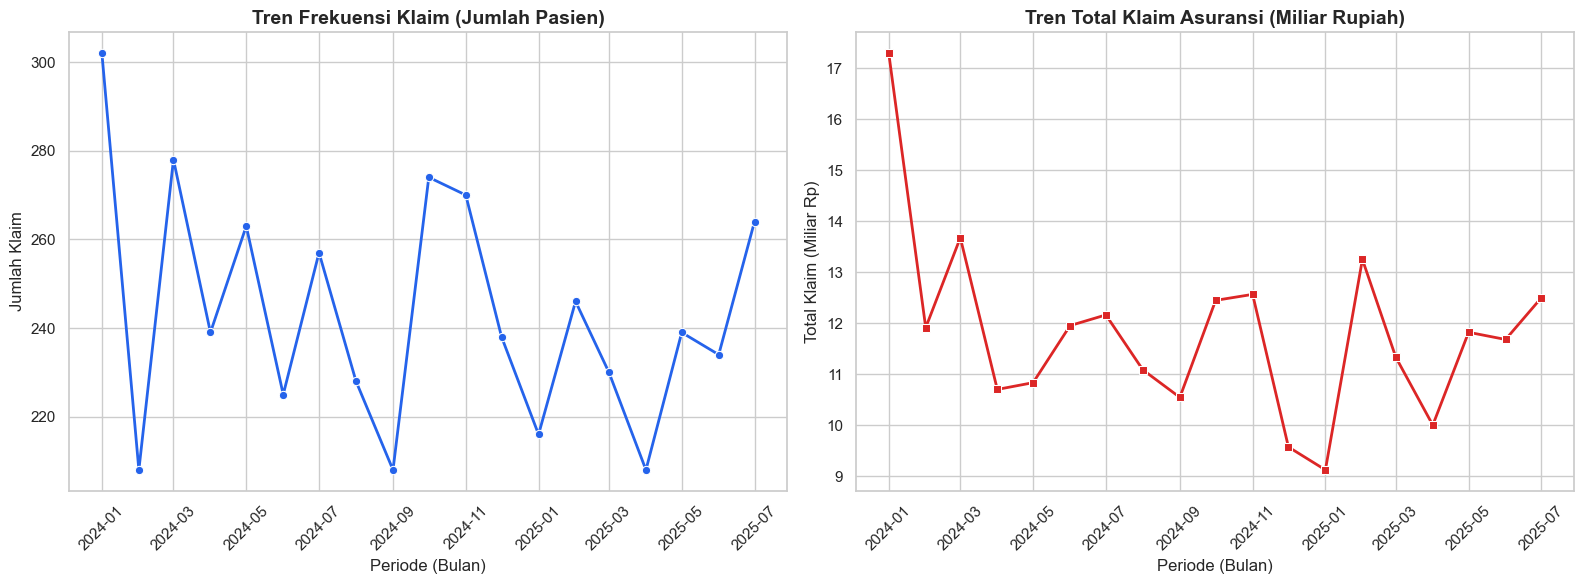

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Frekuensi
sns.lineplot(ax=axes[0], data=monthly_data, x='Date', y='Claim_Frequency', marker='o', color='#2563eb', linewidth=2)
axes[0].set_title('Tren Frekuensi Klaim (Jumlah Pasien)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Periode (Bulan)')
axes[0].set_ylabel('Jumlah Klaim')
axes[0].tick_params(axis='x', rotation=45)

# Plot Total Klaim
sns.lineplot(ax=axes[1], data=monthly_data, x='Date', y='Total_Claim_B', marker='s', color='#dc2626', linewidth=2)
axes[1].set_title('Tren Total Klaim Asuransi (Miliar Rupiah)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Periode (Bulan)')
axes[1].set_ylabel('Total Klaim (Miliar Rp)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 4. Feature Engineering
Membuat fitur berbasis waktu (Time-Series) untuk dipelajari oleh Machine Learning:
- **Lag Features (1, 2, 3, 6):** Model melihat histori klaim 1, 2, 3, dan 6 bulan ke belakang sebagai referensi.
- **Rolling Mean 3:** Memuluskan pergerakan momentum 3 bulan terakhir.

In [4]:
def create_features(df):
    df = df.copy()
    df['Month'] = df['Date'].dt.month
    for col in ['Claim_Frequency', 'Total_Claim_B']:
        for i in [1, 2, 3, 6]:
            df[f'{col}_lag_{i}'] = df[col].shift(i)
        df[f'{col}_roll_mean_3'] = df[col].shift(1).rolling(window=3).mean()
    return df

ts_data = create_features(monthly_data)
display(ts_data.head())

,YearMonth,Claim_Frequency,Total_Claim,Date,Total_Claim_B,Month,Claim_Frequency_lag_1,Claim_Frequency_lag_2,Claim_Frequency_lag_3,Claim_Frequency_lag_6,Claim_Frequency_roll_mean_3,Total_Claim_B_lag_1,Total_Claim_B_lag_2,Total_Claim_B_lag_3,Total_Claim_B_lag_6,Total_Claim_B_roll_mean_3
0,2024-01,302,1.729727e+10,2024-01-01,17.297272,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-02,208,1.191458e+10,2024-02-01,11.914581,2,302.0,NaN,NaN,NaN,NaN,17.297272,NaN,NaN,NaN,NaN
2,2024-03,278,1.367896e+10,2024-03-01,13.678962,3,208.0,302.0,NaN,NaN,NaN,11.914581,17.297272,NaN,NaN,NaN
3,2024-04,239,1.070358e+10,2024-04-01,10.703581,4,278.0,208.0,302.0,NaN,262.666667,13.678962,11.914581,17.297272,NaN,14.296938
4,2024-05,263,1.083650e+10,2024-05-01,10.836501,5,239.0,278.0,208.0,NaN,241.666667,10.703581,13.678962,11.914581,NaN,12.099041


## 5. Pemodelan (Arsitektur 2 Model Ensemble)

Dataset asuransi berukuran sangat kecil (hanya ~40 bulan historis) namun memiliki tren inflasi yang kuat. Menggunakan model *Decision Tree* murni (seperti XGBoost) akan gagal total karena mereka tidak dapat mengekstrapolasi tren (cenderung menebak garis mendatar/flatline di masa depan). 

Oleh karena itu, pendekatan ini menggabungkan dua model fundamental yang paling kokoh:

### 1. Model Regresi Linear Autoregressive (Bobot Total 70%)
Model ini terdiri dari **Bayesian Ridge (40%)** dan **Ridge Regressor (30%)**.
- **Cara Kerja:** Model ini disuapi dengan fitur *Lag* (histori) dan *Rolling Mean*. Model akan menghitung korelasi matematis antara angka bulan lalu dengan bulan ini, lalu menarik "garis lurus" menuju masa depan.
- **Keunggulan (Ridge):** Terdapat penalti regularisasi (*alpha*) yang mencegah algoritma bereaksi berlebihan (overfitting) terhadap spike data sesaat.
- **Keunggulan (Bayesian):** Menggunakan distribusi Gaussian untuk mengestimasi parameter, sehingga lebih tahan terhadap ketidakpastian (noise) pada dataset kecil.

### 2. Model Holt-Winters Damped Trend (Bobot 30%)
Ini adalah model *Exponential Smoothing* murni dari ranah statistika time-series klasik.
- **Cara Kerja:** Berfungsi sebagai *Anchor* (Jangkar Makro). Holt-Winters melihat seluruh bentuk historis kurva asuransi secara utuh.
- **Keunggulan (Damped Feature):** Parameter `damped_trend=True` secara matematis memaksa proyeksi inflasi masa depan untuk **perlahan melandai (mengerem)**. Ini adalah pengaman absolut yang mencegah model Regresi Linear terbang tanpa batas ke atas (mencegah *Over-prediction* ekstrem).

In [5]:
months_to_predict = ['2025-08-01', '2025-09-01', '2025-10-01', '2025-11-01', '2025-12-01']
targets = ['Claim_Frequency', 'Total_Claim_B']

current_ts_data = ts_data.copy()
final_preds = {'2025_08': {}, '2025_09': {}, '2025_10': {}, '2025_11': {}, '2025_12': {}}

print("Memulai Forecasting Multi-Step (Recursive)...")
for i, pred_date in enumerate(months_to_predict):
    if not (current_ts_data['Date'] == pred_date).any():
        new_row = pd.DataFrame({'Date': [pd.to_datetime(pred_date)]})
        current_ts_data = pd.concat([current_ts_data, new_row], ignore_index=True)
        
    temp_df = create_features(current_ts_data)
    exclude_cols = ['YearMonth', 'Date', 'Claim_Frequency', 'Total_Claim', 'Total_Claim_B']
    features = [c for c in temp_df.columns if c not in exclude_cols]
    
    for target in targets:
        # Siapkan data latih berjalan
        train_df = temp_df[temp_df['Date'] < pred_date].dropna()
        X_train = train_df[features]
        y_train = train_df[target]
        X_test = temp_df[temp_df['Date'] == pred_date][features].fillna(0)
        
        # --- MODEL 1: Autoregressive Linear ---
        bayes = make_pipeline(StandardScaler(), BayesianRidge()).fit(X_train, y_train)
        ridge = make_pipeline(StandardScaler(), Ridge(alpha=1.0)).fit(X_train, y_train)
        
        pred_bayes = bayes.predict(X_test)[0]
        pred_ridge = ridge.predict(X_test)[0]
        
        # --- MODEL 2: Holt-Winters Damped ---
        try:
            hw_model = ExponentialSmoothing(y_train.values, trend='add', damped_trend=True, initialization_method='estimated').fit(optimized=True)
            pred_hw = hw_model.forecast(1)[0]
        except:
            # Fallback jika optimisasi parameter statistika gagal
            pred_hw = y_train.values[-1]
            
        # --- THE ENSEMBLE BLEND ---
        final_val = (0.40 * pred_bayes) + (0.30 * pred_ridge) + (0.30 * pred_hw)
        
        # Simpan prediksi untuk iterasi rekursif (sebagai Lag di bulan berikutnya)
        current_ts_data.loc[current_ts_data['Date'] == pred_date, target] = final_val
        
        target_name = 'Claim_Frequency' if target == 'Claim_Frequency' else 'Total_Claim'
        if target == 'Total_Claim_B':
            final_val = final_val * 1e9  # Konversi kembali ke nominal Rupiah asli
            
        month_key = pred_date[:7].replace('-', '_')
        final_preds[month_key][target_name] = final_val

print("Forecasting Selesai.")

Memulai Forecasting Multi-Step (Recursive)...
Forecasting Selesai.


## 6. Kalkulasi Severity & Export CSV
Langkah terakhir adalah menghitung `Claim_Severity` (Biaya rata-rata per pasien) menggunakan rumus dasar aktuaria:
**Severity = Total Claim / Claim Frequency**

Selanjutnya seluruh hasil diformat menjadi `.csv` untuk dinilai oleh sistem.

In [6]:
submission_rows = []
print("\n--- HASIL AKHIR PREDIKSI KLAIM Q4 2025 ---")
print("=" * 65)

for month_key in final_preds.keys():
    freq = final_preds[month_key]['Claim_Frequency']
    total = final_preds[month_key]['Total_Claim']
    
    # Kalkulasi Severity
    sev = total / freq if freq > 0 else 0
    
    print(f"{month_key} -> Freq: {freq:,.1f} | Sev: Rp {sev:,.0f} | Total: Rp {total:,.0f}")
    
    submission_rows.append({'id': f'{month_key}_Claim_Frequency', 'value': freq})
    submission_rows.append({'id': f'{month_key}_Claim_Severity', 'value': sev})
    submission_rows.append({'id': f'{month_key}_Total_Claim', 'value': total})

print("=" * 65)

submission_df = pd.DataFrame(submission_rows)
submission_df.to_csv('submission_ta4_final.csv', index=False)
print("\n[SUKSES] File 'submission_ta4_final.csv' telah berhasil di-export!")


--- HASIL AKHIR PREDIKSI KLAIM Q4 2025 ---
2025_08 -> Freq: 233.3 | Sev: Rp 45,937,643 | Total: Rp 10,715,774,358
2025_09 -> Freq: 239.0 | Sev: Rp 45,798,069 | Total: Rp 10,947,876,007
2025_10 -> Freq: 245.2 | Sev: Rp 47,684,733 | Total: Rp 11,691,492,854
2025_11 -> Freq: 246.1 | Sev: Rp 47,946,698 | Total: Rp 11,797,429,796
2025_12 -> Freq: 244.6 | Sev: Rp 46,603,206 | Total: Rp 11,399,910,291

[SUKSES] File 'submission_ta4_final.csv' telah berhasil di-export!
